<a href="https://colab.research.google.com/github/ciril7/Elkanio-Internship/blob/main/Excercise%203/CustomerSegmentation_And_Anomoly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving customer_data_with_errors.csv to customer_data_with_errors (1).csv
Dataset Shape: (520, 3)

First 5 Rows:
   Feature_1  Feature_2  CustomerID
0  -3.042906   8.524800         253
1  -2.166663   9.695626          14
2  -8.194149   6.707614         235
3  -7.647885  -5.827233         316
4  -8.758546   6.903450         491

Missing Values:
Feature_1     6
Feature_2     8
CustomerID    0
dtype: int64

Missing Values After Cleaning:
Feature_1     0
Feature_2     0
CustomerID    0
dtype: int64

Cluster Counts:
Cluster
0    505
1     10
2      5
Name: count, dtype: int64


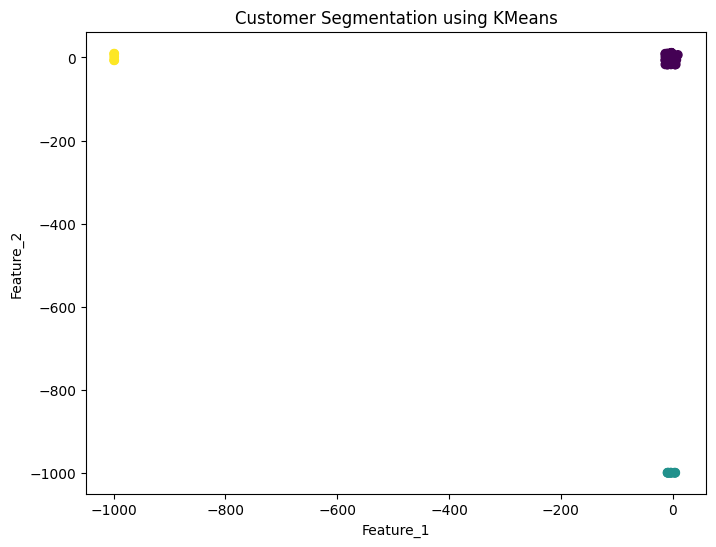


Anomaly Counts:
Anomaly
 1    504
-1     16
Name: count, dtype: int64


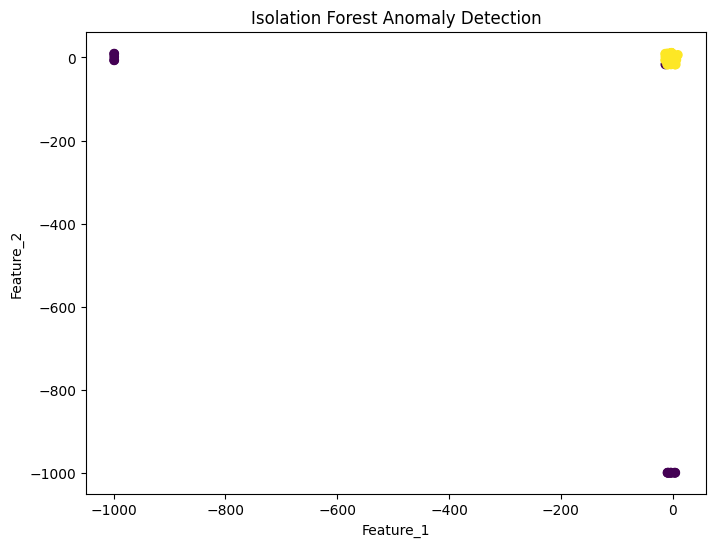


REPORT SUMMARY
1. Missing values handled using mean imputation.
2. Customers segmented into 3 clusters using KMeans.
3. Isolation Forest used to detect unusual customers.
4. Anomalies labelled as -1 and normal customers as 1.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from google.colab import files

# Upload Dataset
uploaded = files.upload()

# Load Dataset
df = pd.read_csv('/content/customer_data_with_errors.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# Data Cleaning
# -----------------------------
imputer = SimpleImputer(strategy='mean')

df[['Feature_1','Feature_2']] = imputer.fit_transform(
    df[['Feature_1','Feature_2']]
)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# -----------------------------
# Feature Selection
# -----------------------------
X = df[['Feature_1','Feature_2']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# KMeans Clustering
# -----------------------------
kmeans = KMeans(n_clusters=3,
                random_state=42,
                n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nCluster Counts:")
print(df['Cluster'].value_counts())

# Plot Clusters
plt.figure(figsize=(8,6))

plt.scatter(df['Feature_1'],
            df['Feature_2'],
            c=df['Cluster'])

plt.title("Customer Segmentation using KMeans")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.show()

# -----------------------------
# Anomaly Detection
# -----------------------------
iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

anomaly = iso.fit_predict(X_scaled)

df['Anomaly'] = anomaly

print("\nAnomaly Counts:")
print(df['Anomaly'].value_counts())

# Plot Anomalies
plt.figure(figsize=(8,6))

plt.scatter(df['Feature_1'],
            df['Feature_2'],
            c=df['Anomaly'])

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.show()

# -----------------------------
# Report Summary
# -----------------------------
print("\nREPORT SUMMARY")
print("1. Missing values handled using mean imputation.")
print("2. Customers segmented into 3 clusters using KMeans.")
print("3. Isolation Forest used to detect unusual customers.")
print("4. Anomalies labelled as -1 and normal customers as 1.")